# Lab 4, Day 1 — Regression on California Housing

Build an MLP regressor in PyTorch, then compare it head-to-head against your own Lab 2
NumPy gradient descent code on the exact same data. See `Lab4_Day1_Instructions.md`
for the full walkthrough.

This notebook is just a shell: it gives you a place to call and plot your functions,
but the loading, model, training loop, and comparison are yours to write.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

## Step 1: Load and preprocess (`stage_a_regression.py`)

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
california_housing = fetch_california_housing(as_frame = True)
print(california_housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [4]:
california_housing.frame.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# TODO: load California Housing, split train/test, fit_transform the scaler on
# train only, transform test, reshape targets to (n, 1)

from stage_a_regression import load_data
torch.manual_seed(0)
np.random.seed(0)

x_train, y_train, x_test, y_test = load_data(test_split=0.2)


## Step 2-3: Model, loss, optimizer, training loop

In [6]:
# TODO: build_mlp from train.py (or write it directly), train with train_full_batch,
# store loss.item() each epoch - not the tensor itself

from stage_a_regression import build_mlp
from train import training

EPOCH = 100
BATCH_SIZE = 32

train_data = TensorDataset(x_train, y_train)

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

train_data, val_data = random_split(
    train_data,
    [train_size, val_size]
)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

model = build_mlp([8, 32, 1])
model = model.to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

history = training(
        model = model,
        train_loader = train_loader,
        val_loader = val_loader,
        epochs = EPOCH,
        optimizer = optimizer,
        loss_fn = loss_fn,
        device=device,
    )



Training: 100%|██████████| 100/100 [01:38<00:00,  1.02it/s, epoch=100, train_loss=0.2928, val_loss=0.3022]


In [7]:
from stage_a_regression import main, load_data

x_train, y_train, x_test, y_test = load_data()
model, history = main(x_train, y_train, x_test, y_test, epoch=1000)

Training: 100%|██████████| 1000/1000 [02:15<00:00,  7.38it/s, epoch=1000, train_loss=0.2808, val_loss=0.3002]

the test loss is -  0.2852151691913605


## Step 4: Evaluate and plot

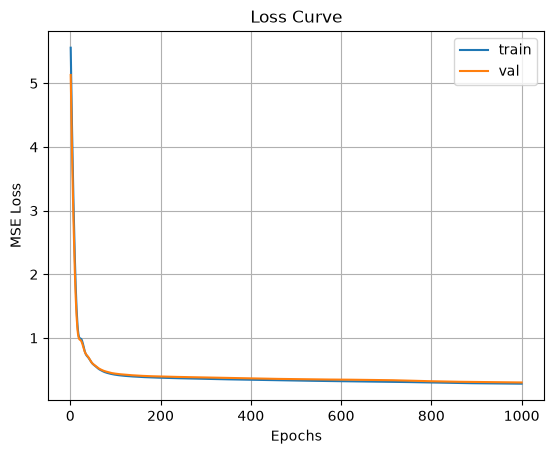

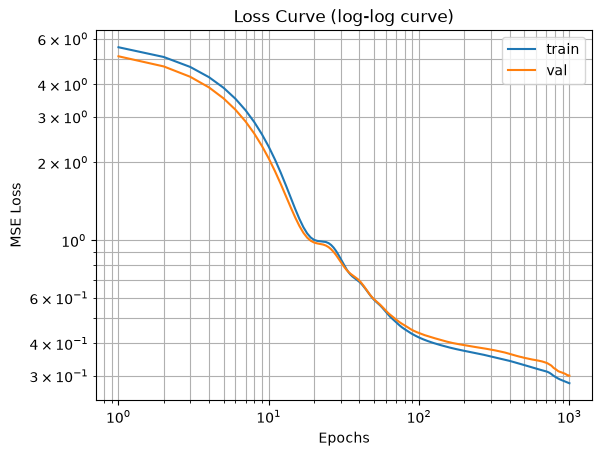

In [8]:
# TODO: model.eval() + torch.no_grad() to get test MSE; plot the training loss curve


epochs = np.arange(1, len(history['train_loss'])+1, 1)
plt.plot(epochs, history['train_loss'], label='train')
plt.plot(epochs, history['val_loss'], label='val')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid()
plt.show()

plt.plot(epochs, history['train_loss'], label='train')
plt.plot(epochs, history['val_loss'], label='val')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.xscale('log')
plt.yscale('log')
plt.title('Loss Curve (log-log curve)')
plt.legend()
plt.grid(which='both')
plt.show()


## Step 5: Compare against your Lab 2 NumPy code

In [ ]:
# TODO: fit a linear model on the same preprocessed data using your own hand-derived
# gradient descent, compare test MSE against the MLP, plot both curves side by side


In [9]:
torch.save(model.state_dict(), "stage_a.pt")

>Your MLP barely beats the linear model, and might lose to it. What would have to be true about this data for the MLP to win decisively — and what does that tell you about when a neural network is the right tool?
>
>
>* The MLP would win decisively if the relationship between the features and the target were strongly non-linear or if there were important interactions between features that a simple linear model could not capture. 
>* In that case, the extra layers and non-linear activation of the neural network would allow it to learn patterns that the linear model cannot. 
>* This shows that neural networks are most useful when the data contains complex, non-linear relationships and we have enough data to learn those patterns. 
>* If the underlying relationship is already close to linear, a neural network adds unnecessary complexity and may even overfit, so a simpler model can be just as good or better.




---
**Before you close this notebook today:** save your trained model
(`torch.save(model.state_dict(), "stage_a.pt")`), and run the Fashion-MNIST loader
once (see `Lab4_Day2_Instructions.md` Step 1) so it's cached before Day 2. Keep this
notebook - Day 2 is a new notebook in the same folder.

In [31]:
from torchvision import datasets, transforms
datasets.FashionMNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
datasets.FashionMNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

100.0%
100.0%
100.0%
100.0%


Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()